7.Text Analytics

1.Extract Sample document and apply following document preprocessing methods:
Tokenization, POS Tagging, stop words removal, Stemming and Lemmatization.

2.Create representation of document by calculating Term Frequency and Inverse Document
Frequency

In [3]:
# Importing necessary libraries
import nltk
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import math

# Downloading required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [5]:
# Sample documents for analysis
documents = [
    "Text analytics helps in extracting useful information from unstructured data.",
    "Natural language processing involves text analytics and machine learning techniques.",
    "Data analytics is useful in various applications such as business intelligence and decision making.",
    "Tokenization is the first step in text analytics and NLP pipelines."
]

# Display the documents
print("Sample Documents:")
for i, doc in enumerate(documents):
    print(f"Document {i+1}: {doc}")

Sample Documents:
Document 1: Text analytics helps in extracting useful information from unstructured data.
Document 2: Natural language processing involves text analytics and machine learning techniques.
Document 3: Data analytics is useful in various applications such as business intelligence and decision making.
Document 4: Tokenization is the first step in text analytics and NLP pipelines.


In [7]:
# Function to perform text preprocessing
def preprocess_text(text):
    # Removing special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Converting to lowercase
    text = text.lower()
    return text

# Apply preprocessing to all documents
preprocessed_docs = [preprocess_text(doc) for doc in documents]

# Display preprocessed documents
print("\nPreprocessed Documents:")
for i, doc in enumerate(preprocessed_docs):
    print(f"Document {i+1}: {doc}")


Preprocessed Documents:
Document 1: text analytics helps in extracting useful information from unstructured data
Document 2: natural language processing involves text analytics and machine learning techniques
Document 3: data analytics is useful in various applications such as business intelligence and decision making
Document 4: tokenization is the first step in text analytics and nlp pipelines


In [8]:
# 1. Tokenization

# Simple word tokenization (using split)
word_tokens = []
for doc in preprocessed_docs:
    # Basic tokenization by splitting on spaces
    tokens = doc.split()
    word_tokens.append(tokens)

# Simple sentence tokenization
sent_tokens = []
for doc in documents:
    # Split on common sentence-ending punctuation
    sentences = re.split(r'(?<=[.!?])\s+', doc)
    sent_tokens.append(sentences)

# Display the results
print("\n--- TOKENIZATION ---")
print("\nWord Tokenization (for Document 1):")
print(word_tokens[0])

print("\nSentence Tokenization (for all documents):")
for i, sentences in enumerate(sent_tokens):
    print(f"\nDocument {i+1}:")
    for j, sentence in enumerate(sentences):
        print(f"  Sentence {j+1}: {sentence}")

# Character tokenization for first document
char_tokens = list(documents[0])
print("\nCharacter Tokenization (for Document 1):")
print(char_tokens)


--- TOKENIZATION ---

Word Tokenization (for Document 1):
['text', 'analytics', 'helps', 'in', 'extracting', 'useful', 'information', 'from', 'unstructured', 'data']

Sentence Tokenization (for all documents):

Document 1:
  Sentence 1: Text analytics helps in extracting useful information from unstructured data.

Document 2:
  Sentence 1: Natural language processing involves text analytics and machine learning techniques.

Document 3:
  Sentence 1: Data analytics is useful in various applications such as business intelligence and decision making.

Document 4:
  Sentence 1: Tokenization is the first step in text analytics and NLP pipelines.

Character Tokenization (for Document 1):
['T', 'e', 'x', 't', ' ', 'a', 'n', 'a', 'l', 'y', 't', 'i', 'c', 's', ' ', 'h', 'e', 'l', 'p', 's', ' ', 'i', 'n', ' ', 'e', 'x', 't', 'r', 'a', 'c', 't', 'i', 'n', 'g', ' ', 'u', 's', 'e', 'f', 'u', 'l', ' ', 'i', 'n', 'f', 'o', 'r', 'm', 'a', 't', 'i', 'o', 'n', ' ', 'f', 'r', 'o', 'm', ' ', 'u', 'n', 's

In [9]:
# 2. POS Tagging
# Define a simple function for POS tagging
def simple_pos_tag(tokens):
    # Very basic POS tagging
    pos_tags = []
    for token in tokens:
        # Some simple rules
        if token.lower() in ['the', 'a', 'an']:
            pos_tags.append((token, 'DT'))  # Determiner
        elif token.lower() in ['is', 'are', 'was', 'were', 'am', 'be', 'being', 'been', 'helps', 'involves']:
            pos_tags.append((token, 'VB'))  # Verb
        elif token.lower() in ['in', 'on', 'at', 'by', 'with', 'from']:
            pos_tags.append((token, 'IN'))  # Preposition
        elif token.lower() in ['and', 'or', 'but', 'yet', 'so']:
            pos_tags.append((token, 'CC'))  # Conjunction
        elif token.lower().endswith('ing'):
            pos_tags.append((token, 'VBG'))  # Gerund
        elif token.lower().endswith('ly'):
            pos_tags.append((token, 'RB'))  # Adverb
        elif token.lower().endswith(('s', 'es')):
            pos_tags.append((token, 'NNS'))  # Plural noun
        else:
            pos_tags.append((token, 'NN'))  # Default to noun
    return pos_tags

# Apply POS tagging to each document
pos_tagged_docs = []
for doc_tokens in word_tokens:
    pos_tagged_docs.append(simple_pos_tag(doc_tokens))

print("\n--- POS TAGGING ---")
print("\nPOS Tags for Document 1:")
print(pos_tagged_docs[0])


--- POS TAGGING ---

POS Tags for Document 1:
[('text', 'NN'), ('analytics', 'NNS'), ('helps', 'VB'), ('in', 'IN'), ('extracting', 'VBG'), ('useful', 'NN'), ('information', 'NN'), ('from', 'IN'), ('unstructured', 'NN'), ('data', 'NN')]


In [10]:
# 3. Stop Words Removal
# Define English stop words
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 
    'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 
    'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 
    'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 
    'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 
    'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 
    "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y'
])

# Remove stop words from each document
filtered_docs = []
for doc_tokens in word_tokens:
    filtered_tokens = [token for token in doc_tokens if token not in stop_words]
    filtered_docs.append(filtered_tokens)

print("\n--- STOP WORDS REMOVAL ---")
print("\nDocument 1 before stop word removal:")
print(word_tokens[0])
print("\nDocument 1 after stop word removal:")
print(filtered_docs[0])


--- STOP WORDS REMOVAL ---

Document 1 before stop word removal:
['text', 'analytics', 'helps', 'in', 'extracting', 'useful', 'information', 'from', 'unstructured', 'data']

Document 1 after stop word removal:
['text', 'analytics', 'helps', 'extracting', 'useful', 'information', 'unstructured', 'data']


In [11]:
# 4. Stemming
# Apply Porter Stemmer to each document
stemmer = PorterStemmer()
stemmed_docs = []
for doc_tokens in filtered_docs:
    stemmed_tokens = [stemmer.stem(token) for token in doc_tokens]
    stemmed_docs.append(stemmed_tokens)

print("\n--- STEMMING ---")
print("\nDocument 1 before stemming:")
print(filtered_docs[0])
print("\nDocument 1 after stemming:")
print(stemmed_docs[0])

# Examples of stemming
example_words = ["program", "programming", "programmed", "programs", "programmer"]
print("\nStemming examples:")
for word in example_words:
    print(f"{word} -> {stemmer.stem(word)}")


--- STEMMING ---

Document 1 before stemming:
['text', 'analytics', 'helps', 'extracting', 'useful', 'information', 'unstructured', 'data']

Document 1 after stemming:
['text', 'analyt', 'help', 'extract', 'use', 'inform', 'unstructur', 'data']

Stemming examples:
program -> program
programming -> program
programmed -> program
programs -> program
programmer -> programm


In [12]:
# 5. Lemmatization
# Define a simple lemmatization function
def simple_lemmatize(word):
    # Very basic lemmatization rules
    if word.endswith('ing'):
        return word[:-3]  # Remove 'ing'
    elif word.endswith('s') and not word.endswith('ss'):
        return word[:-1]  # Remove trailing 's'
    elif word.endswith('es'):
        return word[:-2]  # Remove 'es'
    elif word.endswith('ies'):
        return word[:-3] + 'y'  # Change 'ies' to 'y'
    elif word.endswith('ed') and len(word) > 4:
        return word[:-2]  # Remove 'ed'
    else:
        return word

# Apply lemmatization to each document
lemmatized_docs = []
for doc_tokens in filtered_docs:
    lemmatized_tokens = [simple_lemmatize(token) for token in doc_tokens]
    lemmatized_docs.append(lemmatized_tokens)

print("\n--- LEMMATIZATION ---")
print("\nDocument 1 before lemmatization:")
print(filtered_docs[0])
print("\nDocument 1 after lemmatization:")
print(lemmatized_docs[0])

# Examples of lemmatization
example_words = ["studies", "studying", "studied", "cries", "crying", "cried"]
print("\nLemmatization examples:")
for word in example_words:
    print(f"{word} -> {simple_lemmatize(word)}")


--- LEMMATIZATION ---

Document 1 before lemmatization:
['text', 'analytics', 'helps', 'extracting', 'useful', 'information', 'unstructured', 'data']

Document 1 after lemmatization:
['text', 'analytic', 'help', 'extract', 'useful', 'information', 'unstructur', 'data']

Lemmatization examples:
studies -> studie
studying -> study
studied -> studi
cries -> crie
crying -> cry
cried -> cri


In [14]:
# 6. Term Frequency (TF) Calculation
def compute_tf(document):
    # Count the frequency of each word in the document
    tf = {}
    total_words = len(document)
    for word in document:
        if word in tf:
            tf[word] += 1
        else:
            tf[word] = 1
    
    # Normalize the counts
    for word, count in tf.items():
        tf[word] = count / total_words
    
    return tf

# Calculate TF for each document
tf_docs = []
for doc in stemmed_docs:
    tf_docs.append(compute_tf(doc))

print("\n--- TERM FREQUENCY (TF) ---")
print("\nTF for Document 1:")
for word, score in tf_docs[0].items():
    print(f"{word}: {score:.4f}")


--- TERM FREQUENCY (TF) ---

TF for Document 1:
text: 0.1250
analyt: 0.1250
help: 0.1250
extract: 0.1250
use: 0.1250
inform: 0.1250
unstructur: 0.1250
data: 0.1250


In [15]:
# 7. Inverse Document Frequency (IDF) Calculation
def compute_idf(documents):
    # Calculate how many documents contain each word
    word_in_docs = {}
    for doc in documents:
        unique_words = set(doc)
        for word in unique_words:
            if word in word_in_docs:
                word_in_docs[word] += 1
            else:
                word_in_docs[word] = 1
    
    # Calculate IDF for each word
    total_docs = len(documents)
    idf = {}
    for word, doc_count in word_in_docs.items():
        idf[word] = math.log(total_docs / doc_count)
    
    return idf

# Calculate IDF
idf = compute_idf(stemmed_docs)

print("\n--- INVERSE DOCUMENT FREQUENCY (IDF) ---")
print("\nIDF for all terms:")
for word, score in idf.items():
    print(f"{word}: {score:.4f}")


--- INVERSE DOCUMENT FREQUENCY (IDF) ---

IDF for all terms:
inform: 1.3863
extract: 1.3863
unstructur: 1.3863
help: 1.3863
use: 0.6931
text: 0.2877
analyt: 0.0000
data: 0.6931
learn: 1.3863
machin: 1.3863
involv: 1.3863
natur: 1.3863
languag: 1.3863
process: 1.3863
techniqu: 1.3863
make: 1.3863
applic: 1.3863
busi: 1.3863
decis: 1.3863
intellig: 1.3863
variou: 1.3863
step: 1.3863
token: 1.3863
pipelin: 1.3863
nlp: 1.3863
first: 1.3863


In [16]:
# 8. TF-IDF Calculation
def compute_tfidf(tf, idf):
    tfidf = {}
    for word, tf_value in tf.items():
        if word in idf:
            tfidf[word] = tf_value * idf[word]
    return tfidf

# Calculate TF-IDF for each document
tfidf_docs = []
for tf_doc in tf_docs:
    tfidf_docs.append(compute_tfidf(tf_doc, idf))

print("\n--- TF-IDF SCORES ---")
print("\nTF-IDF for Document 1:")
for word, score in tfidf_docs[0].items():
    print(f"{word}: {score:.4f}")


--- TF-IDF SCORES ---

TF-IDF for Document 1:
text: 0.0360
analyt: 0.0000
help: 0.1733
extract: 0.1733
use: 0.0866
inform: 0.1733
unstructur: 0.1733
data: 0.0866



--- TF-IDF MATRIX ---
            analyt    applic      busi      data     decis   extract  \
Document 1     0.0  0.000000  0.000000  0.086643  0.000000  0.173287   
Document 2     0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
Document 3     0.0  0.154033  0.154033  0.077016  0.154033  0.000000   
Document 4     0.0  0.000000  0.000000  0.000000  0.000000  0.000000   

               first      help    inform  intellig  ...       nlp   pipelin  \
Document 1  0.000000  0.173287  0.173287  0.000000  ...  0.000000  0.000000   
Document 2  0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.000000   
Document 3  0.000000  0.000000  0.000000  0.154033  ...  0.000000  0.000000   
Document 4  0.198042  0.000000  0.000000  0.000000  ...  0.198042  0.198042   

             process      step  techniqu      text     token  unstructur  \
Document 1  0.000000  0.000000  0.000000  0.035960  0.000000    0.173287   
Document 2  0.154033  0.000000  0.154033  0.031965  0.000000    0.00

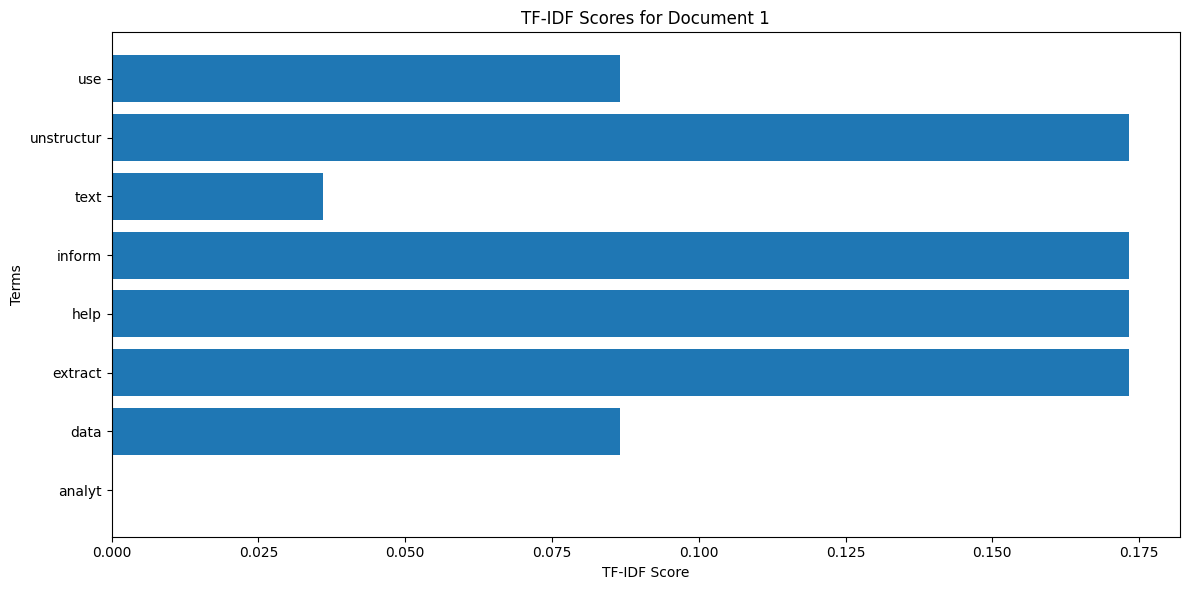

In [17]:
# 9. Create a DataFrame to display TF-IDF results
# Get all unique words across documents
all_words = set()
for doc in stemmed_docs:
    all_words.update(doc)

# Create a DataFrame
tfidf_df = pd.DataFrame(0.0, index=["Document " + str(i+1) for i in range(len(documents))], 
                         columns=sorted(list(all_words)))

# Fill the DataFrame with TF-IDF values
for i, doc_tfidf in enumerate(tfidf_docs):
    for word, score in doc_tfidf.items():
        tfidf_df.loc["Document " + str(i+1), word] = score

print("\n--- TF-IDF MATRIX ---")
print(tfidf_df)

# Visualize the TF-IDF scores for the first document
plt.figure(figsize=(12, 6))
plt.barh(sorted(list(tfidf_docs[0].keys())), 
         [tfidf_docs[0][word] for word in sorted(list(tfidf_docs[0].keys()))])
plt.title('TF-IDF Scores for Document 1')
plt.xlabel('TF-IDF Score')
plt.ylabel('Terms')
plt.tight_layout()
plt.show()


--- CONCLUSION ---
In this Text Analytics practical, we have successfully implemented:
1. Document Preprocessing Techniques:
   - Tokenization (word, sentence, and character level)
   - Part-of-Speech (POS) Tagging
   - Stop Words Removal
   - Stemming using Porter Stemmer
   - Basic Lemmatization
2. Document Representation:
   - Term Frequency (TF) calculation
   - Inverse Document Frequency (IDF) calculation
   - TF-IDF computation and visualization

These techniques form the foundation of text analytics pipelines and are essential for
preparing unstructured text data for various NLP tasks such as text classification,
information retrieval, sentiment analysis, and topic modeling.


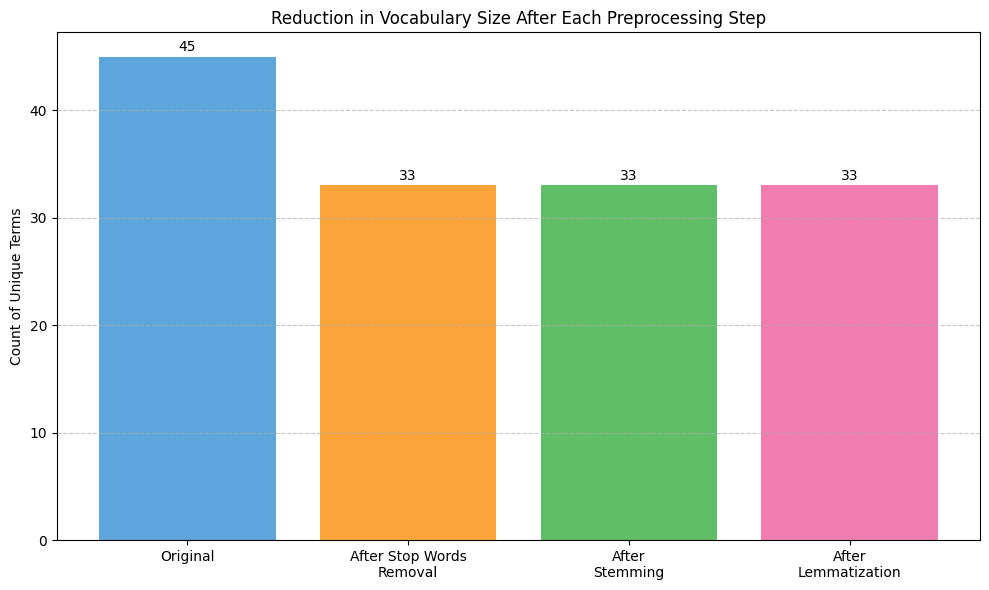

In [18]:
# Conclusion
print("\n--- CONCLUSION ---")
print("In this Text Analytics practical, we have successfully implemented:")
print("1. Document Preprocessing Techniques:")
print("   - Tokenization (word, sentence, and character level)")
print("   - Part-of-Speech (POS) Tagging")
print("   - Stop Words Removal")
print("   - Stemming using Porter Stemmer")
print("   - Basic Lemmatization")
print("2. Document Representation:")
print("   - Term Frequency (TF) calculation")
print("   - Inverse Document Frequency (IDF) calculation")
print("   - TF-IDF computation and visualization")
print("\nThese techniques form the foundation of text analytics pipelines and are essential for")
print("preparing unstructured text data for various NLP tasks such as text classification,")
print("information retrieval, sentiment analysis, and topic modeling.")

# Create a summary figure with key metrics
plt.figure(figsize=(10, 6))
# Count unique terms after each preprocessing step
original_terms = sum([len(set(doc.split())) for doc in preprocessed_docs])
after_stopwords = sum([len(set(doc)) for doc in filtered_docs])
after_stemming = sum([len(set(doc)) for doc in stemmed_docs])
after_lemma = sum([len(set(doc)) for doc in lemmatized_docs])

# Create bar chart showing reduction in vocabulary size
counts = [original_terms, after_stopwords, after_stemming, after_lemma]
labels = ['Original', 'After Stop Words\nRemoval', 'After\nStemming', 'After\nLemmatization']
plt.bar(labels, counts, color=['#5DA5DA', '#FAA43A', '#60BD68', '#F17CB0'])
plt.title('Reduction in Vocabulary Size After Each Preprocessing Step')
plt.ylabel('Count of Unique Terms')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center')

plt.tight_layout()
plt.show()